# Exploratory Data Analysis (EDA) - Geldium Collections

This Notebook contains the initial data exploration steps for the Tata iQ GenAI Data Analytics simulation. The goal is to understand dataset completeness, handle missing values, and uncover initial patterns related to credit card delinquency.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style
sns.set_theme(style="whitegrid")

# 1. Load the Dataset
Loading the provided customer financial dataset to inspect its structure.

In [2]:
# Load dataset
df = pd.read_excel('Delinquency_prediction_dataset.xlsx')

# Display the first 5 rows
df.head()

,Customer_ID,Age,Income,Credit_Score,Credit_Utilization,Missed_Payments,Delinquent_Account,Loan_Balance,Debt_to_Income_Ratio,Employment_Status,Account_Tenure,Credit_Card_Type,Location,Month_1,Month_2,Month_3,Month_4,Month_5,Month_6
0,CUST0001,56,165580.0,398.0,0.390502,3,0,16310.0,0.317396,EMP,18,Student,Los Angeles,Late,Late,Missed,Late,Missed,Late
1,CUST0002,69,100999.0,493.0,0.312444,6,1,17401.0,0.196093,Self-employed,0,Standard,Phoenix,Missed,Missed,Late,Missed,On-time,On-time
2,CUST0003,46,188416.0,500.0,0.359930,0,0,13761.0,0.301655,Self-employed,1,Platinum,Chicago,Missed,Late,Late,On-time,Missed,Late
3,CUST0004,32,101672.0,413.0,0.371400,3,0,88778.0,0.264794,Unemployed,15,Platinum,Phoenix,Late,Missed,Late,Missed,Late,Late
4,CUST0005,60,38524.0,487.0,0.234716,2,0,13316.0,0.510583,Self-employed,11,Standard,Phoenix,Missed,On-time,Missed,Late,Late,Late


# 2. Missing Data Analysis
Identifying gaps in critical features such as Income and Loan Balance that require imputation.

In [3]:
# Check for missing values and their percentages
missing_data = df.isnull().sum()
missing_percent = (missing_data / len(df)) * 100

missing_df = pd.DataFrame({'Missing Values': missing_data, 'Percentage (%)': missing_percent})
print(missing_df[missing_df['Missing Values'] > 0])

              Missing Values  Percentage (%)
Income                    39             7.8
Credit_Score               2             0.4
Loan_Balance              29             5.8


# 3. Risk Factor Profiling: Employment Status vs. Delinquency
Analyzing how employment stability impacts the likelihood of a customer falling into delinquency.

/var/folders/t_/gy7pzp996r30jq3vc4dyx6gr0000gn/T/ipykernel_4997/221837403.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Employment_Status', y='Delinquent_Account', data=df, errorbar=None, palette='viridis')


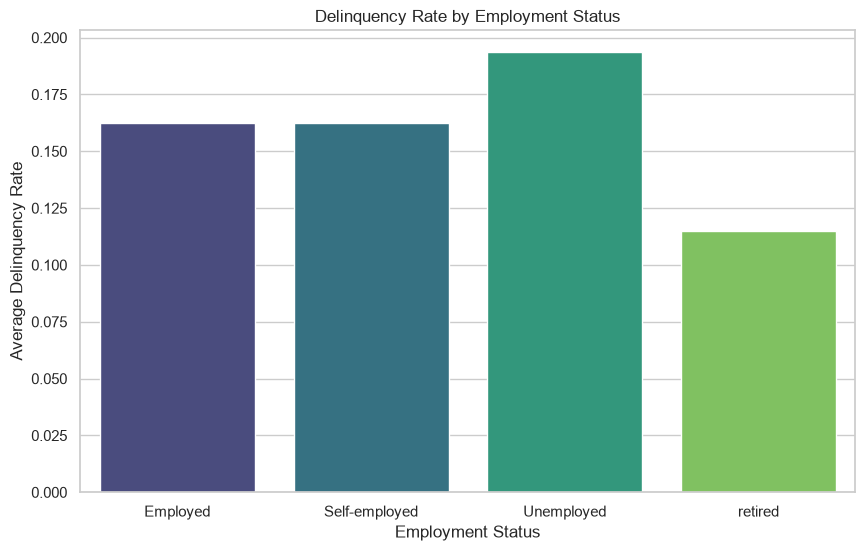

In [4]:
# Clean inconsistent employment status labels (e.g., 'EMP' vs 'Employed')
df['Employment_Status'] = df['Employment_Status'].replace({'EMP': 'Employed', 'employed': 'Employed'})

# Plot delinquency rate by employment status
plt.figure(figsize=(10, 6))
sns.barplot(x='Employment_Status', y='Delinquent_Account', data=df, errorbar=None, palette='viridis')
plt.title('Delinquency Rate by Employment Status')
plt.ylabel('Average Delinquency Rate')
plt.xlabel('Employment Status')
plt.show()

# 4. Correlation of Financial Variables
Checking how factors like Credit Utilization and Debt-to-Income ratio correlate with actual delinquency.

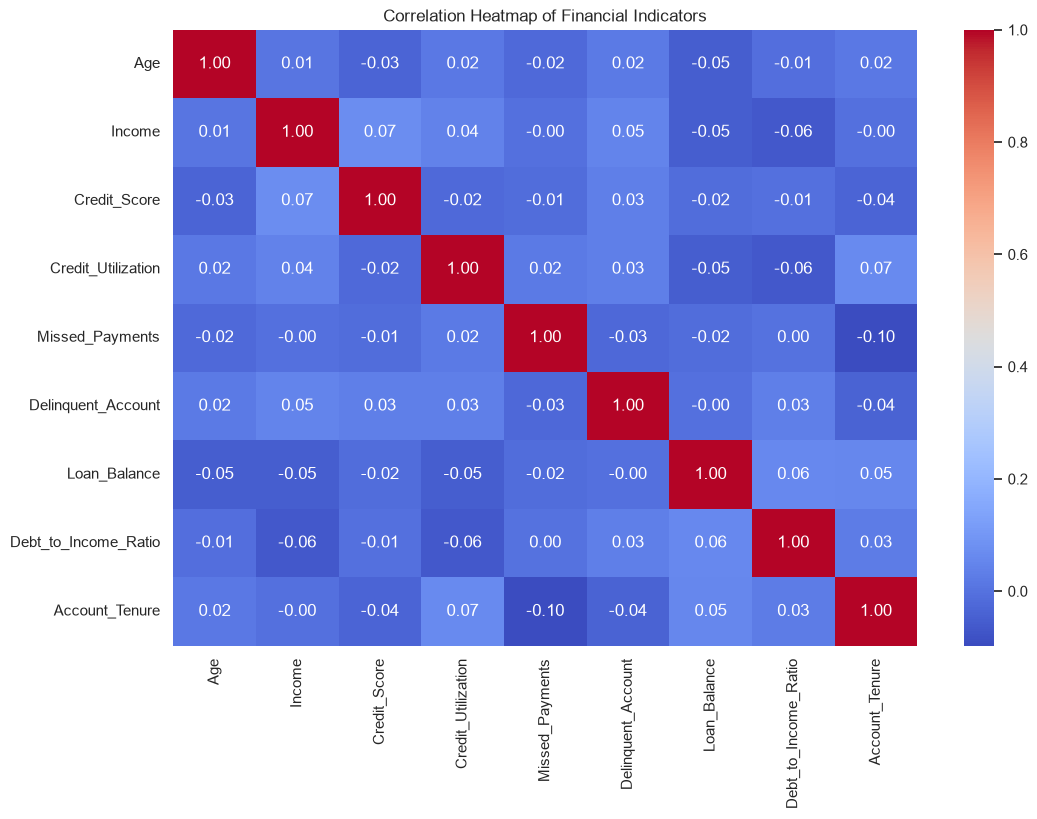

In [5]:
# Select only numerical columns for correlation
numerical_cols = df.select_dtypes(include=['float64', 'int64'])

# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(numerical_cols.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Financial Indicators')
plt.show()